# 1. 概要・目的

本PoCでは、変圧器のオイル温度（OT）の予測を通じて、予防保全への活用可能性を検証する。
公開ベンチマークであるETTデータセットを用い、複数のアプローチで予測モデルを構築・比較した。

# 2. データの読み込みと基礎確認

ETTデータセットの読み込み、基本統計量の確認、欠損値の確認を行う。

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
work_dir = 'drive/MyDrive/Athena Technologies/MLエンジニア選考課題/data'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
etth1 = pd.read_csv(work_dir + '/ETTh1.csv')
etth1.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


# 3. EDA（探索的データ分析）

時系列の可視化、OTと他の負荷特徴量との相関確認、ヒートマップ・散布図による関係性の把握を行う。

In [ ]:
# 基礎統計量の確認
etth1.describe()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
count,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000
mean,7.375141,2.242242,4.300239,0.881568,3.066062,0.856932,13.324672
std,7.067744,2.042342,6.826978,1.809293,1.164506,0.599552,8.566946
min,-22.705999,-4.756000,-25.087999,-5.934000,-1.188000,-1.371000,-4.080000
25%,5.827000,0.737000,3.296000,-0.284000,2.315000,0.670000,6.964000
50%,8.774000,2.210000,5.970000,0.959000,2.833000,0.975000,11.396000
75%,11.788000,3.684000,8.635000,2.203000,3.625000,1.218000,18.079000
max,23.643999,10.114000,17.341000,7.747000,8.498000,3.046000,46.007000


In [ ]:
# 欠損値の確認
etth1.isnull().sum()

,0
date,0
HUFL,0
HULL,0
MUFL,0
MULL,0
LUFL,0
LULL,0
OT,0


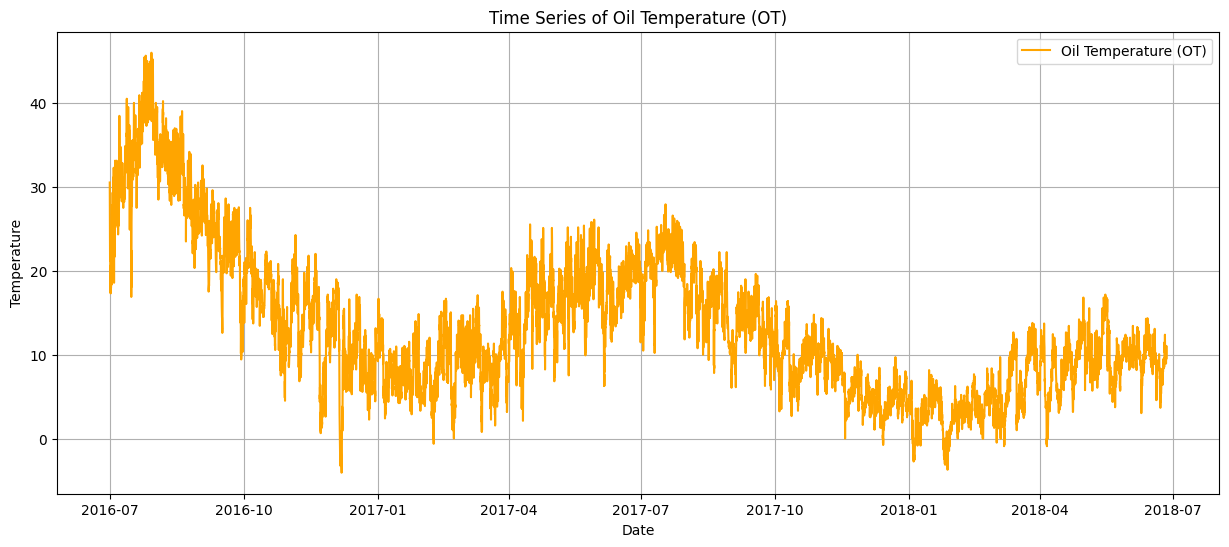

In [ ]:
# 時系列の可視化
plt.figure(figsize=(15, 6))
plt.plot(pd.to_datetime(etth1['date']), etth1['OT'], color='orange', label='Oil Temperature (OT)')
plt.title('Time Series of Oil Temperature (OT)')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# オイル温度（OT）と他の負荷（HUFL, HULL等）の相関を確認

# 数値データのみを対象に計算
corr_matrix = etth1.drop(columns=['date']).corr()

corr_matrix['OT'].sort_values(ascending=False)

,OT
OT,1.000000
HULL,0.224354
MULL,0.220004
LUFL,0.118836
LULL,0.067455
HUFL,0.059916
MUFL,0.050854


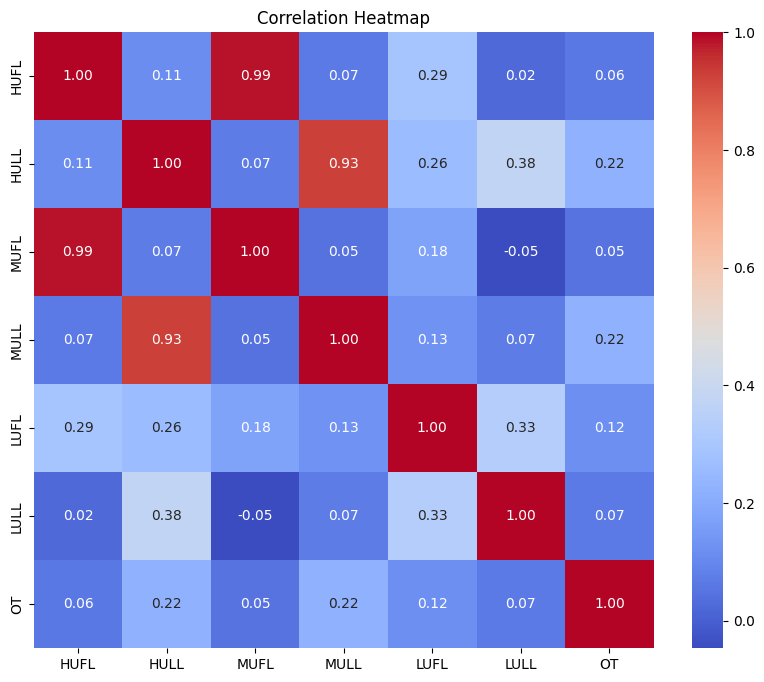

In [ ]:
# 相関をヒートマップで可視化
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

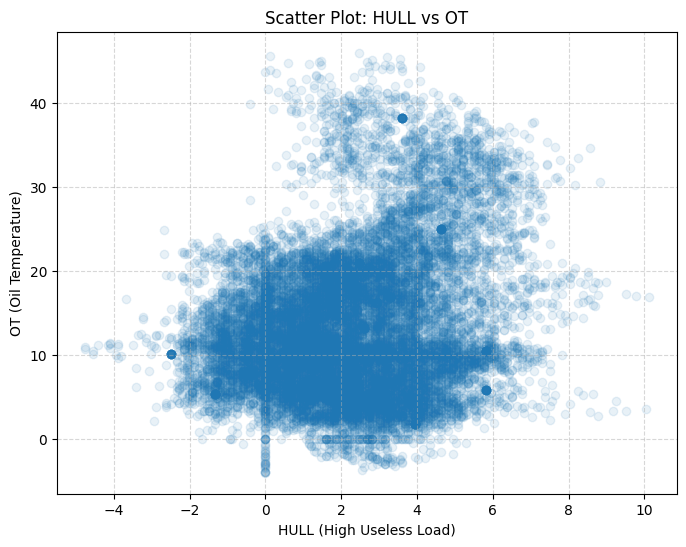

In [ ]:
# 散布図で最も相関が高いと思われる負荷（HULL）との関係を確認
plt.figure(figsize=(8, 6))
plt.scatter(etth1['HULL'], etth1['OT'], alpha=0.1)
plt.title('Scatter Plot: HULL vs OT')
plt.xlabel('HULL (High Useless Load)')
plt.ylabel('OT (Oil Temperature)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 4. ベースラインモデル：線形回帰

特徴量を段階的に追加しながら、線形回帰によるベースラインモデルを構築する（Version1〜3）。

In [ ]:
# 説明変数と目的変数の分離
X = etth1[['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL']]
y = etth1['OT']

In [ ]:
# 時系列順に訓練データ（80%）と検証データ（20%）に分割
test_size = int(len(etth1) * 0.2)
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

In [ ]:
# スケーリング（標準化 / 平均0、標準偏差1に変換）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# ベースラインモデル（線形回帰）の学習
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
# 平均二乗誤差（MSE）による予測評価
# 平均二乗誤差（MSE）が「0」に近いほど、予測精度が高い
preds = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, preds)
print(f'Baseline MSE: {mse}')

Baseline MSE: 83.66166173609382


# 5. 特徴量エンジニアリング

OT_lag1（1時間前のOT）、hour（時間帯）、HUFL_rolling6（移動平均）などの特徴量を作成する。

In [ ]:
# 特徴量エンジニアリング
# 1時間前のオイル温度（OT）を新しい特徴量 'OT_lag1' として作成
etth1['OT_lag1'] = etth1['OT'].shift(1)
etth1 = etth1.dropna().reset_index(drop=True)
etth1[['date', 'OT', 'OT_lag1']].head()

,date,OT,OT_lag1
0,2016-07-01 01:00:00,27.787001,30.531000
1,2016-07-01 02:00:00,27.787001,27.787001
2,2016-07-01 03:00:00,25.044001,27.787001
3,2016-07-01 04:00:00,21.948000,25.044001
4,2016-07-01 05:00:00,21.174000,21.948000


In [ ]:
# 説明変数 X を更新
X = etth1[['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT_lag1']]
y = etth1['OT']

In [ ]:
test_size = int(len(etth1) * 0.2)
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model_v2 = LinearRegression()
model_v2.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
preds_v2 = model_v2.predict(X_test_scaled)
mse_v2 = mean_squared_error(y_test, preds_v2)
print(f'Version2 MSE: {mse_v2}')

Version2 MSE: 0.41851493458132577


In [ ]:
# 特徴量エンジニアリング
# 時間情報を抽出
etth1['hour'] = pd.to_datetime(etth1['date']).dt.hour

In [ ]:
# 特徴量エンジニアリング
# HUFL（高圧・有効負荷）の過去6時間の移動平均（Rolling Mean）を作成
etth1['HUFL_rolling6'] = etth1['HUFL'].rolling(window=6).mean()
etth1 = etth1.dropna().reset_index(drop=True)
etth1[['OT', 'HUFL', 'HUFL_rolling6']].corr()

,OT,HUFL,HUFL_rolling6
OT,1.000000,0.060074,0.049765
HUFL,0.060074,1.000000,0.769524
HUFL_rolling6,0.049765,0.769524,1.000000


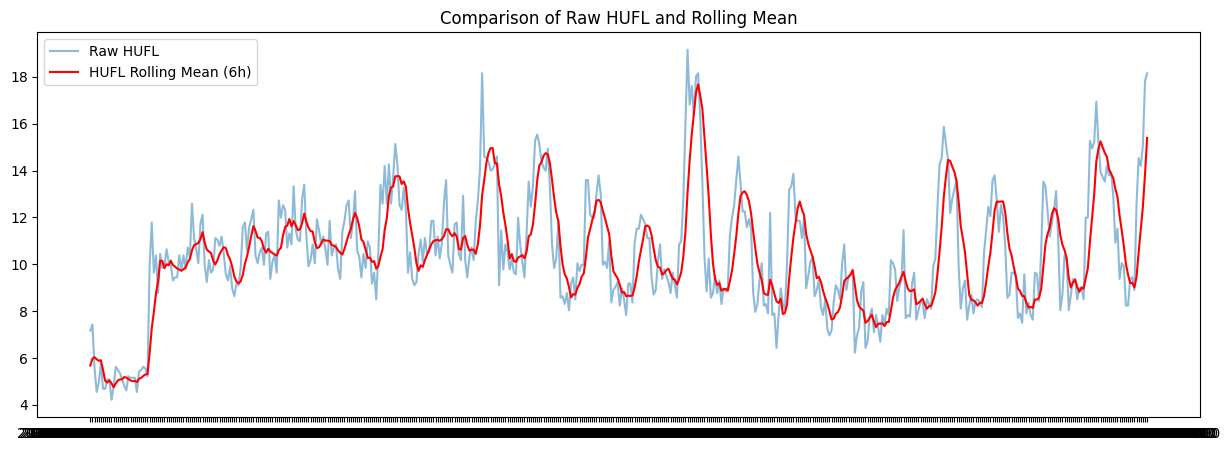

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(etth1['date'][:500], etth1['HUFL'][:500], label='Raw HUFL', alpha=0.5)
plt.plot(etth1['date'][:500], etth1['HUFL_rolling6'][:500], label='HUFL Rolling Mean (6h)', color='red')
plt.title('Comparison of Raw HUFL and Rolling Mean')
plt.legend()
plt.show()

In [ ]:
X = etth1[['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT_lag1', 'hour', 'HUFL_rolling6']]
y = etth1['OT']

In [ ]:
test_size = int(len(etth1) * 0.2)
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model_v3 = LinearRegression()
model_v3.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
preds_v3 = model_v3.predict(X_test_scaled)
mse_v3 = mean_squared_error(y_test, preds_v3)
print(f'Version3 MSE: {mse_v3}')

Version3 MSE: 0.41793328671445684


# 6. 深層学習モデルの実装

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

## 6-1. LSTMの基本実装（MyLSTMCell, MyLSTM）

In [ ]:
# LSTMの基本方程式（1ステップ分のLSTM計算）
class MyLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim

        self.W_i = nn.Linear(input_dim + hidden_dim, hidden_dim) # 入力ゲート（0〜1）
        self.W_f = nn.Linear(input_dim + hidden_dim, hidden_dim) # 忘却ゲート（0〜1）
        self.W_o = nn.Linear(input_dim + hidden_dim, hidden_dim) # 出力ゲート（0〜1）
        self.W_c = nn.Linear(input_dim + hidden_dim, hidden_dim) # 新しく記憶する情報の候補（-1〜1）

    def forward(self, x_t, h_prev, c_prev):
        # x_t   : 現時点の入力                   (batch_size, input_dim)
        # h_prev: 1時点前の隠れ状態（出力情報）  (batch_size, hidden_dim)
        # c_prev: 1時点前のセル状態（長期記憶）  (batch_size, hidden_dim)

        # 現在の入力と1時点前の隠れ状態を結合し、各ゲートに入力
        combined = torch.cat([x_t, h_prev], dim=1)

        i_t = torch.sigmoid(self.W_i(combined))  # 入力ゲート（0〜1）
        f_t = torch.sigmoid(self.W_f(combined))  # 忘却ゲート（0〜1）
        o_t = torch.sigmoid(self.W_o(combined))  # 出力ゲート（0〜1）
        c_hat_t = torch.tanh(self.W_c(combined)) # 新しく記憶する情報の候補（-1〜1）

        # セル状態の更新：過去の記憶の保持分（f_t）＋ 新しい情報の追加分（i_t）
        c_t = f_t * c_prev + i_t * c_hat_t
        # 隠れ状態の更新：更新後のセル状態のうち、出力に使う分だけを取り出す
        h_t = o_t * torch.tanh(c_t)

        return h_t, c_t

In [ ]:
# 1ステップ分のLSTM計算（MyLSTMCell）を時系列全体に対して繰り返し適用
class MyLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = MyLSTMCell(input_dim, hidden_dim)

    def forward(self, x):
        # x: (batch_size, seq_len, input_dim)
        batch_size, seq_len, _ = x.shape

        # 隠れ状態・セル状態を0で初期化
        h = torch.zeros(batch_size, self.hidden_dim, device=x.device)
        c = torch.zeros(batch_size, self.hidden_dim, device=x.device)

        outputs = []
        for t in range(seq_len):
            x_t = x[:, t, :]                # t時点の入力を抽出
            h, c = self.cell(x_t, h, c)     # 1ステップ分計算し、h, cを更新
            outputs.append(h.unsqueeze(1))  # 各時点の隠れ状態を記録

        outputs = torch.cat(outputs, dim=1) # (batch_size, seq_len, hidden_dim) に結合
        return outputs, (h, c)              # outputs: 全時点の隠れ状態の履歴、(h, c): 最終時点の状態

## 6-2. SimpleLSTM（1層LSTM）
PyTorch標準のnn.LSTMを用いた、シンプルな1層LSTMモデル。

In [ ]:
# 基本的な1層LSTMモデル
class SimpleLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=1,        # まずは1層だけ
            batch_first=True,    # 入力の形を (batch, seq_len, input_dim) にする
        )
        self.dropout = nn.Dropout(dropout)          # 過学習防止用のDropout層
        self.fc = nn.Linear(hidden_dim, output_dim) # 隠れ状態を予測値に変換する全結合層

    def forward(self, x):
        # x: (batch, seq_len=24, input_dim=9)
        out, (h_n, c_n) = self.lstm(x)
        # out: (batch, seq_len, hidden_dim)

        last_hidden = out[:, -1, :]   # 最後の時点（24時間目）の隠れ状態だけを使う
        last_hidden = self.dropout(last_hidden)
        pred = self.fc(last_hidden)   # (batch, output_dim) 最終的な予測値に変換
        return pred

## 6-3. UNetResidualLSTMBlock（U-Net型 + 残差接続）
U-Net構造と残差接続を組み合わせた、より複雑なカスタムアーキテクチャ。

In [ ]:
# ResNetの残差接続をLSTMに応用
class ResidualLSTMBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout=0.2):
        super().__init__()
        self.lstm = MyLSTM(input_dim, hidden_dim)

        # LSTM出力(hidden_dim)と入力(input_dim)を足し算するために、次元を揃える
        if input_dim != hidden_dim:
            self.shortcut = nn.Linear(input_dim, hidden_dim) # 次元が違う場合は変換する層を用意
        else:
            self.shortcut = nn.Identity() # 次元が同じ場合は何もせずそのまま使う

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out, _ = self.lstm(x)               # LSTM出力 (batch_size, seq_len, hidden_dim)
        shortcut = self.shortcut(x)         # 入力xを次元変換した出力 (batch_size, seq_len, hidden_dim)
        return self.dropout(out + shortcut) # 残差接続 (out + shortcut) にDropoutを適用

In [ ]:
# U-Net構造を時系列に応用したLSTMモデル
class UNetResidualLSTMBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=1, dropout=0.2):
        super().__init__()
        # エンコーダ部分：時系列を段階的に圧縮しながら特徴を抽出
        self.enc1 = ResidualLSTMBlock(input_dim, hidden_dim, dropout=dropout)
        self.enc2 = ResidualLSTMBlock(hidden_dim, hidden_dim, dropout=dropout)

        # ボトルネック：抽出した特徴量を最大圧縮
        self.bottleneck = ResidualLSTMBlock(hidden_dim, hidden_dim, dropout=dropout)

        # デコーダ部分：特徴量の結合と解像度の復元
        # 入力 hidden_dim*2 ：デコーダの特徴量とスキップ接続を結合
        self.dec1 = ResidualLSTMBlock(hidden_dim * 2, hidden_dim, dropout=dropout)
        self.dec2 = ResidualLSTMBlock(hidden_dim * 2, hidden_dim, dropout=dropout)

        self.head_dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_dim, output_dim)

    def downsample(self, x):
        # 1つ飛ばしで時刻を抜き出し、時系列長を半分にする
        return x[:, ::2, :]

    def upsample(self, x):
        # 各時刻の値を2回繰り返し、時系列長を2倍にする
        return x.repeat_interleave(2, dim=1)

    def forward(self, x):
        # x: (B, T, input_dim)

        # エンコーダ経路
        e1 = self.enc1(x)              # (B, T, H)    スキップ接続用に保存
        x1 = self.downsample(e1)       # (B, T/2, H)

        e2 = self.enc2(x1)             # (B, T/2, H)  スキップ接続用に保存
        x2 = self.downsample(e2)       # (B, T/4, H)

        b = self.bottleneck(x2)        # (B, T/4, H)  最も圧縮された状態

        # デコーダ経路
        u1 = self.upsample(b)          # (B, T/2, H)

        # downsample/upsampleによる時系列のズレを、短い方に合わせて補正
        min_len1 = min(u1.size(1), e2.size(1))
        u1 = u1[:, :min_len1, :]
        e2_crop = e2[:, :min_len1, :]

        d1_in = torch.cat([u1, e2_crop], dim=2)   # スキップ接続：デコーダ出力とe2を結合 (B, T/2, 2H)
        d1 = self.dec1(d1_in)                     # (B, T/2, H)

        u2 = self.upsample(d1)          # (B, T, H)

        min_len2 = min(u2.size(1), e1.size(1))
        u2 = u2[:, :min_len2, :]
        e1_crop = e1[:, :min_len2, :]

        d2_in = torch.cat([u2, e1_crop], dim=2)   # スキップ接続：デコーダ出力とe1を結合 (B, T, 2H)
        d2 = self.dec2(d2_in)                     # (B, T, H)

        # 最終時点の出力を抽出し、予測値に変換
        last_output = d2[:, -1, :]
        last_output = self.head_dropout(last_output)   # Dropout
        y_hat = self.fc(last_output)

        return y_hat

# 7. モデルの学習
目的変数 y の標準化、シーケンスデータの作成を行った上で、各モデルに対して同様の学習設定（勾配クリッピング・学習率スケジューラ・Early Stoppingを導入）で学習を行う。

In [ ]:
# 説明変数 X をテンソルに変換
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# 目的変数 y をテンソルに変換
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

print(f"X_train shape: {X_train_tensor.shape}")
print(f"X_test shape: {X_test_tensor.shape}")

X_train shape: torch.Size([13932, 9])
X_test shape: torch.Size([3482, 9])


In [ ]:
# シーケンスデータの定義
# 時系列データを「過去 window_size 分の入力 → 次の1時刻の正解」のペアに変換
def create_sequences(data, target, window_size):
    X_seq, y_seq = [], []
    for i in range(len(data) - window_size):
        # 過去 window_size 分の特徴量を取得
        X_seq.append(data[i : i + window_size])
        # その直後の時刻のターゲット（OT）を取得
        y_seq.append(target[i + window_size])
    return np.array(X_seq), np.array(y_seq)

In [ ]:
# 目的変数 y をスケーリング（学習データだけでfit、テストはtransformのみ）
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

window_size = 24
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, window_size)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, window_size)

print(f"X_train_seq shape: {X_train_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}")

X_train_seq shape: (13908, 24, 9)
X_test_seq shape: (3458, 24, 9)


In [ ]:
X_train_seq_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_seq_tensor = torch.tensor(y_train_seq, dtype=torch.float32)
X_test_seq_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_seq_tensor = torch.tensor(y_test_seq, dtype=torch.float32)

In [ ]:
# データセットの作成
train_dataset = TensorDataset(X_train_seq_tensor, y_train_seq_tensor)
test_dataset = TensorDataset(X_test_seq_tensor, y_test_seq_tensor)

# DataLoaderの作成（ETTh1をバッチごとに読み込む）
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# SimpleLSTM
simple_model = SimpleLSTM(
    input_dim=9,
    hidden_dim=128,
    output_dim=1,
    dropout=0.2
).to(device)

# UNetResidualLSTMBlock
unet_model = UNetResidualLSTMBlock(
    input_dim=9,
    hidden_dim=128,
    output_dim=1,
    dropout=0.2
).to(device)

# ダミー入力で動作確認
x_dummy = torch.randn(8, 24, 9).to(device)

y_dummy_simple = simple_model(x_dummy)
print('SimpleLSTM:', y_dummy_simple.shape)

y_dummy_unet = unet_model(x_dummy)
print('UNetResidualLSTMBlock:', y_dummy_unet.shape)

SimpleLSTM: torch.Size([8, 1])
UNetResidualLSTMBlock: torch.Size([8, 1])


## 7-1. SimpleLSTMの学習

In [ ]:
# SimpleLSTMの学習
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(simple_model.parameters(), lr=1e-4, weight_decay=1e-5)

# 学習率スケジューラを追加（test lossが下がらなくなったらlrを下げる）
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # lossは小さいほど良いので'min'
    factor=0.5,       # lrを半分にする
    patience=5,       # 5エポック改善がなければ下げる
)

num_epochs = 200
early_stop_patience = 15   # 15エポック改善がなければ停止
best_test_mse = float('inf')
epochs_no_improve = 0

for epoch in range(num_epochs):
    # 訓練データ
    total_train_loss = 0.0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # 予測
        pred = simple_model(batch_x)

        # 損失
        loss = criterion(pred.squeeze(), batch_y.float())

        # 勾配の初期化
        optimizer.zero_grad()

        # 誤差逆伝播
        loss.backward()

        # 勾配クリッピング（モデルパラメータの勾配全体のノルムが1.0を超えたら縮小）
        torch.nn.utils.clip_grad_norm_(simple_model.parameters(), max_norm=1.0)

        # パラメータ更新
        optimizer.step()

        # 損失の合計
        total_train_loss += loss.item() * batch_x.size(0)

    # 検証データ
    total_test_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            pred = simple_model(batch_x)
            loss = criterion(pred.squeeze(), batch_y.float())
            total_test_loss += loss.item() * batch_x.size(0)

    # 1エポックあたりの平均MSEと、RMSE（MSEの正の平方根）
    # 訓練データ
    avg_train_mse = total_train_loss / len(train_loader.dataset)
    train_rmse = np.sqrt(avg_train_mse)

    # 検証データ
    avg_test_mse = total_test_loss / len(test_loader.dataset)
    test_rmse = np.sqrt(avg_test_mse)

    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'  [Train] MSE: {avg_train_mse:.6f}, RMSE: {train_rmse:.4f}')
    print(f'  [Test ] MSE: {avg_test_mse:.6f}, RMSE: {test_rmse:.4f}')

    # スケジューラにtest lossを渡す
    scheduler.step(avg_test_mse)
    current_lr = optimizer.param_groups[0]['lr']
    print(f'  [LR   ] {current_lr:.2e}')

    # Early Stoppingの判定
    if avg_test_mse < best_test_mse:
        best_test_mse = avg_test_mse
        epochs_no_improve = 0
        torch.save(simple_model.state_dict(), 'best_simple_model.pt')
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= early_stop_patience:
        print(f'Early stopping at epoch {epoch+1}')
        break

Epoch 1/200
  [Train] MSE: 0.270327, RMSE: 0.5199
  [Test ] MSE: 0.029246, RMSE: 0.1710
  [LR   ] 1.00e-04
Epoch 2/200
  [Train] MSE: 0.043522, RMSE: 0.2086
  [Test ] MSE: 0.023063, RMSE: 0.1519
  [LR   ] 1.00e-04
Epoch 3/200
  [Train] MSE: 0.038586, RMSE: 0.1964
  [Test ] MSE: 0.020094, RMSE: 0.1418
  [LR   ] 1.00e-04
Epoch 4/200
  [Train] MSE: 0.036108, RMSE: 0.1900
  [Test ] MSE: 0.020372, RMSE: 0.1427
  [LR   ] 1.00e-04
Epoch 5/200
  [Train] MSE: 0.034112, RMSE: 0.1847
  [Test ] MSE: 0.020221, RMSE: 0.1422
  [LR   ] 1.00e-04
Epoch 6/200
  [Train] MSE: 0.032472, RMSE: 0.1802
  [Test ] MSE: 0.019056, RMSE: 0.1380
  [LR   ] 1.00e-04
Epoch 7/200
  [Train] MSE: 0.031116, RMSE: 0.1764
  [Test ] MSE: 0.018406, RMSE: 0.1357
  [LR   ] 1.00e-04
Epoch 8/200
  [Train] MSE: 0.030305, RMSE: 0.1741
  [Test ] MSE: 0.018045, RMSE: 0.1343
  [LR   ] 1.00e-04
Epoch 9/200
  [Train] MSE: 0.029397, RMSE: 0.1715
  [Test ] MSE: 0.016673, RMSE: 0.1291
  [LR   ] 1.00e-04
Epoch 10/200
  [Train] MSE: 0.028629,

## 7-2. UNetResidualLSTMBlockの学習

In [ ]:
# UNetResidualLSTMBlockの学習
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(unet_model.parameters(), lr=1e-4, weight_decay=1e-5)

# 学習率スケジューラを追加（test lossが下がらなくなったらlrを下げる）
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # lossは小さいほど良いので'min'
    factor=0.5,       # lrを半分にする
    patience=5,       # 5エポック改善がなければ下げる
)

num_epochs = 200
early_stop_patience = 15   # 15エポック改善がなければ停止
best_test_mse = float('inf')
epochs_no_improve = 0

for epoch in range(num_epochs):
    # 訓練データ
    total_train_loss = 0.0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # 予測
        pred = unet_model(batch_x)

        # 損失
        loss = criterion(pred.squeeze(), batch_y.float())

        # 勾配の初期化
        optimizer.zero_grad()

        # 誤差逆伝播
        loss.backward()

        # 勾配クリッピング（モデルパラメータの勾配全体のノルムが1.0を超えたら縮小）
        torch.nn.utils.clip_grad_norm_(unet_model.parameters(), max_norm=1.0)

        # パラメータ更新
        optimizer.step()

        # 損失の合計
        total_train_loss += loss.item() * batch_x.size(0)

    # 検証データ
    total_test_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            pred = unet_model(batch_x)
            loss = criterion(pred.squeeze(), batch_y.float())
            total_test_loss += loss.item() * batch_x.size(0)

    # 1エポックあたりの平均MSEと、RMSE（MSEの正の平方根）
    # 訓練データ
    avg_train_mse = total_train_loss / len(train_loader.dataset)
    train_rmse = np.sqrt(avg_train_mse)

    # 検証データ
    avg_test_mse = total_test_loss / len(test_loader.dataset)
    test_rmse = np.sqrt(avg_test_mse)

    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'  [Train] MSE: {avg_train_mse:.6f}, RMSE: {train_rmse:.4f}')
    print(f'  [Test ] MSE: {avg_test_mse:.6f}, RMSE: {test_rmse:.4f}')

    # スケジューラにtest lossを渡す
    scheduler.step(avg_test_mse)
    current_lr = optimizer.param_groups[0]['lr']
    print(f'  [LR   ] {current_lr:.2e}')

    # Early Stoppingの判定
    if avg_test_mse < best_test_mse:
        best_test_mse = avg_test_mse
        epochs_no_improve = 0
        torch.save(unet_model.state_dict(), 'best_unet_model.pt')
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= early_stop_patience:
        print(f'Early stopping at epoch {epoch+1}')
        break

Epoch 1/200
  [Train] MSE: 0.083152, RMSE: 0.2884
  [Test ] MSE: 0.038367, RMSE: 0.1959
  [LR   ] 1.00e-04
Epoch 2/200
  [Train] MSE: 0.044600, RMSE: 0.2112
  [Test ] MSE: 0.029335, RMSE: 0.1713
  [LR   ] 1.00e-04
Epoch 3/200
  [Train] MSE: 0.039609, RMSE: 0.1990
  [Test ] MSE: 0.025428, RMSE: 0.1595
  [LR   ] 1.00e-04
Epoch 4/200
  [Train] MSE: 0.036956, RMSE: 0.1922
  [Test ] MSE: 0.024024, RMSE: 0.1550
  [LR   ] 1.00e-04
Epoch 5/200
  [Train] MSE: 0.035075, RMSE: 0.1873
  [Test ] MSE: 0.022995, RMSE: 0.1516
  [LR   ] 1.00e-04
Epoch 6/200
  [Train] MSE: 0.034158, RMSE: 0.1848
  [Test ] MSE: 0.021682, RMSE: 0.1472
  [LR   ] 1.00e-04
Epoch 7/200
  [Train] MSE: 0.032860, RMSE: 0.1813
  [Test ] MSE: 0.021059, RMSE: 0.1451
  [LR   ] 1.00e-04
Epoch 8/200
  [Train] MSE: 0.032074, RMSE: 0.1791
  [Test ] MSE: 0.020051, RMSE: 0.1416
  [LR   ] 1.00e-04
Epoch 9/200
  [Train] MSE: 0.031170, RMSE: 0.1765
  [Test ] MSE: 0.019411, RMSE: 0.1393
  [LR   ] 1.00e-04
Epoch 10/200
  [Train] MSE: 0.030545,

In [ ]:
def evaluate_real_scale_mse(model, model_name, checkpoint_path, test_loader, y_scaler):
    model.load_state_dict(torch.load(checkpoint_path)) # 保存済みのベストモデルを読み込む
    model.eval() # 評価モードにする（Dropoutを無効化）

    all_preds = []
    all_true = []

    # テストデータ全体に対する予測値・実測値を集める
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            pred = model(batch_x)
            all_preds.append(pred.cpu().numpy())
            all_true.append(batch_y.numpy())

    all_preds = np.concatenate(all_preds).reshape(-1, 1)
    all_true = np.concatenate(all_true).reshape(-1, 1)

    # スケーリング（標準化）前の単位（℃）に復元
    preds_real = y_scaler.inverse_transform(all_preds)
    true_real = y_scaler.inverse_transform(all_true)

    mse_real = mean_squared_error(true_real, preds_real)
    rmse_real = np.sqrt(mse_real)

    print(f'[{model_name}] 検証 MSE: {mse_real:.5f}')
    print(f'[{model_name}] 検証 RMSE: {rmse_real:.5f} ℃')

    return mse_real, rmse_real

# 8. モデル評価・比較

スケーリング前の単位（℃）でのMSE/RMSEを算出し、線形回帰・SimpleLSTM・UNetResidualLSTMBlockの3モデルを比較する。

In [ ]:
# 最終評価：スケーリング前の単位（℃）での MSE/RMSE
# SimpleLSTM
mse_simple_real, rmse_simple_real = evaluate_real_scale_mse(
    simple_model, 'SimpleLSTM', 'best_simple_model.pt', test_loader, y_scaler
)

# UNetResidualLSTMBlock
mse_unet_real, rmse_unet_real = evaluate_real_scale_mse(
    unet_model, 'UNetLSTMBlock', 'best_unet_model.pt', test_loader, y_scaler
)

[SimpleLSTM] 検証 MSE: 0.71654
[SimpleLSTM] 検証 RMSE: 0.84648 ℃
[UNetLSTMBlock] 検証 MSE: 0.72581
[UNetLSTMBlock] 検証 RMSE: 0.85195 ℃


In [ ]:
model_info = {
    'Model': ['LinearRegression', 'SimpleLSTM', 'UNetResidualLSTMBlock'],
    'MSE': [round(mse_v3, 4), round(mse_simple_real, 4), round(mse_unet_real, 4)],
    'RMSE (℃)': [round(np.sqrt(mse_v3), 4), round(rmse_simple_real, 4), round(rmse_unet_real, 4)]
}

score_df = pd.DataFrame(model_info)
score_df = score_df.sort_values(by='RMSE (℃)', ascending=True)
score_df = score_df.reset_index(drop=True)

score_df

,Model,MSE,RMSE (℃)
0,LinearRegression,0.4179,0.6465
1,SimpleLSTM,0.7165,0.8465
2,UNetResidualLSTMBlock,0.7258,0.8519


# 9. 考察・まとめ

結果の解釈、工夫した点・設計上の意思決定、現時点での限界と今後の改善方針について述べる。

## 工夫した点・設計上の意思決定

- **段階的な比較設計**
  * 精度の高いモデルを最初から目指すのではなく、線形回帰 → SimpleLSTM → UNetResidualLSTMBlockの順に複雑さを上げ、各段階で精度を比較することで、「複雑さに対して精度がどう変化するか」を検証できる設計にした。

- **目的変数のスケーリング**
  * 学習を安定させるため、説明変数だけでなく目的変数（OT）も標準化した。これにより、勾配の更新が適切なスケールで行われるようになった。

- **学習の安定化**
  * 勾配クリッピング・学習率スケジューラ（ReduceLROnPlateau）・Early Stoppingを導入し、過学習や学習の停滞を防ぐ仕組みを整えた。

- **評価指標の単位統一**
  * 学習中は標準化スケールでのMSEを使用したが、最終的な比較は元の℃スケールに逆変換してから行い、線形回帰と公平に比較できるようにした。


## 現時点での限界・今後の改善方針

- **結果の解釈**
  * 本検証では、線形回帰（OT_lag1を用いたシンプルな手法）が、LSTM系の2モデルよりも高い精度を示した。これは、本データにおいてOTの変動が直前の値に強く依存する自己回帰的な性質を持つためと考えられる。一方で、これは「深層学習が不要」という結論ではなく、「本タスクの時間スケール・データ量においては、シンプルな手法が優位だった」という限定的な知見である。

- **ハイパーパラメータの探索不足**
  * window_size（24時間）やhidden_dim（128）は試行的に決めた値であり、網羅的な探索は行っていない。これらを調整することで、LSTM系モデルの精度が改善する可能性がある。

- **予測対象の限定**
  * 本検証では「1時間後のOT」のみを予測対象としたが、実運用での予防保全では、より長い予測期間（例：数時間〜数日先）が求められる可能性がある。多段階予測への拡張が今後の課題である。

- **データ量とモデル複雑さのバランス**
  * LSTM、特にUNetResidualLSTMBlockのような複雑な構造は、一般的に多くのデータを必要とする。今回のデータ規模（約14,000サンプル）では、複雑なモデルの強みが十分に発揮されなかった可能性があり、データを増やした場合の再検証が望まれる。

- **運用上の示唆**
  * 今回最も精度が高かった線形回帰は、計算コストが低く、解釈性も高いため、実運用への導入コストの観点でも有利である。
  * 予防保全システムへの組み込みを検討する際は、精度だけでなく運用コストも踏まえた選定が望ましい。
